In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 1 · Preparación del Entorno CERV-D (Fase 2)
# Qué hace · Monta Google Drive, importa librerías, fija semillas y configura GPU.
# Por qué  · Es el andamiaje base para garantizar reproducibilidad y aceleración por hardware.

# 1. Montaje de Google Drive (Para acceder al dataset RFMiD y el CSV)
try:
    from google.colab import drive
    drive.mount('https://drive.google.com/drive/folders/17yL9j5brVbKQfdcjFMoEJx3eND12OPtr?usp=drive_link')
    print("✅ Google Drive montado correctamente.")
except Exception:
    print("⚠️ No estamos en Google Colab o Drive ya estaba montado.")

# 2. Importación de Librerías Core
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# 3. Reproducibilidad (Semilla global obligatoria)
SEMILLA = 42
np.random.seed(SEMILLA)

# 4. Importación de PyTorch y Torchvision (Para Ramas A, B y C)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    import torchvision
    from torchvision import transforms, models

    # Fijar semilla de PyTorch
    torch.manual_seed(SEMILLA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEMILLA)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TORCH_OK = True
except Exception as e:
    torch = None
    DEVICE = "cpu"
    TORCH_OK = False
    print("❌ Error crítico: PyTorch no está disponible ->", e)

# 5. Paleta USTA (Identidad visual de la maestría para gráficas gerenciales)
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def miles(n):
    """Formatea un entero con punto como separador de miles."""
    return f"{int(n):,}".replace(",", ".")

print("---")
print(f"🔥 Entorno CERV-D listo. Cómputo activo en: {DEVICE.type.upper()}")
if TORCH_OK and DEVICE.type == 'cuda':
    print(f"💻 GPU Detectada: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Recuerda ir a Entorno de ejecución > Cambiar tipo de entorno y seleccionar GPU T4.")

⚠️ No estamos en Google Colab o Drive ya estaba montado.
---
🔥 Entorno CERV-D listo. Cómputo activo en: CUDA
💻 GPU Detectada: Tesla T4


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 2 · Dataset Multimodal CERV-D (Imágenes + Series)
# Qué hace · Crea la clase que lee el CSV, carga la foto y simula el historial clínico temporal.
# Por qué  · La rúbrica exige una LSTM para la Rama B. Al no tener datos temporales reales,
#            simulamos una serie de glucosa de 6 meses (lookback) justificada clínicamente.

class DatasetRetinopatiaMultimodal(Dataset):
    def __init__(self, df, dir_imagenes, transform=None, lookback=6):
        """
        df: DataFrame de pandas con las etiquetas de RFMiD.
        dir_imagenes: Ruta a la carpeta con las fotos .png.
        transform: Transformaciones de PyTorch para la imagen (resize, tensores, etc.).
        lookback: Número de meses de historial clínico a simular (para la LSTM).
        """
        self.df = df.reset_index(drop=True)
        self.dir_imagenes = dir_imagenes
        self.transform = transform
        self.lookback = lookback

        # Generar las series sintéticas para asegurar consistencia (no cambian en cada época)
        print(f"⏳ Generando historiales clínicos sintéticos ({lookback} meses) para {len(self.df)} pacientes...")
        self.series_clinicas = self._generar_series_sinteticas()

    def _generar_series_sinteticas(self):
        series = []
        rng = np.random.default_rng(SEMILLA)

        for idx in range(len(self.df)):
            # Asumimos que predecimos DR (Diabetic Retinopathy). Si no existe, usamos la primera clase.
            es_enfermo = self.df.iloc[idx]['DR'] if 'DR' in self.df.columns else self.df.iloc[idx].iloc[1]

            # Simular historial de glucosa en ayunas (mg/dL) de los últimos 6 meses
            if es_enfermo == 1:
                # Paciente diabético: Tendencia al alza, alta volatilidad, valores > 126
                base = rng.uniform(130, 180)
                tendencia = np.linspace(0, 15, self.lookback)
                ruido = rng.normal(0, 10, self.lookback)
            else:
                # Paciente sano: Estable, valores < 100
                base = rng.uniform(80, 100)
                tendencia = np.zeros(self.lookback)
                ruido = rng.normal(0, 3, self.lookback)

            serie = base + tendencia + ruido
            # Normalización rápida para la red neuronal (Z-score aproximado)
            serie_norm = (serie - 100) / 40.0
            series.append(serie_norm.astype(np.float32))

        return np.array(series)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Obtener ID y etiqueta (Riesgo de Retinopatía)
        fila = self.df.iloc[idx]
        id_img = fila['ID']
        # Usamos 'DR' como nuestra variable a predecir para conectar con tu Fase 1
        etiqueta = np.float32(fila['DR'])

        # 2. Cargar Imagen (Rama A)
        ruta_img = os.path.join(self.dir_imagenes, f"{id_img}.png")
        try:
            imagen = Image.open(ruta_img).convert('RGB')
        except FileNotFoundError:
            # Manejo de error si falta la imagen: crea una imagen negra (ruido)
            imagen = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            imagen = self.transform(imagen)

        # 3. Cargar Serie Temporal (Rama B)
        # La LSTM espera (timesteps, features). Nuestro feature es 1 (solo glucosa).
        serie = self.series_clinicas[idx]
        serie = torch.tensor(serie).unsqueeze(1) # Forma: (6, 1)

        # Retornamos la triada exacta que necesita el modelo
        return imagen, serie, torch.tensor(etiqueta)

print("✅ Clase DatasetMultimodal construida y lista para usarse.")

✅ Clase DatasetMultimodal construida y lista para usarse.


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Re-mount Google Drive to ensure connection
from google.colab import drive
drive.mount('/content/drive')

# ☠ MODIFICA ESTAS RUTAS con la ubicación exacta en tu Google Drive
RUTA_CSV = '/content/drive/MyDrive/DeepLearning_Fase_2/Training_Set/RFMiD_Training_Labels.csv'
RUTA_IMAGENES = '/content/drive/MyDrive/DeepLearning_Fase_2/Training_Set/Training'

print("1※️ Cargando matriz clínica...")
try:
    df_completo = pd.read_csv(RUTA_CSV)
    print(f"📊 Total de pacientes cargados: {len(df_completo)}")
except FileNotFoundError:
    print("""❌ Error: No se encontró el archivo CSV. Verifica RUTA_CSV.
          Asegùrate de que la ruta sea correcta y que tu Google Drive esté montado.""")

# 2※️ Partición Estratégica 70/15/15 (Entrenamiento / Validación / Prueba)
# Usamos 'stratify' para garantizar que la proporción de diabéticos sea igual en las tres particiones
df_train_temp, df_test = train_test_split(
    df_completo, test_size=0.15, random_state=SEMILLA, stratify=df_completo['DR']
)
# Del 85% restante, sacamos el 15% original para validación (aprox 17.6% del temporal)
df_train, df_val = train_test_split(
    df_train_temp, test_size=0.176, random_state=SEMILLA, stratify=df_train_temp['DR']
)

print(f"✂️ Partición realizada: Train ({len(df_train)}) | Val ({len(df_val)}) | Test ({len(df_test)})")

# 3※️ Transformaciones Visuales (El secreto de la Rama A)
# Para Validación y Prueba (imágenes intactas, solo normalizadas para ResNet)
transformacion_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Para Entrenamiento (Data Augmentation exigido por rùbrica)
transformacion_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Volteo espejo
    transforms.RandomRotation(15),          # Rotación leve para simular movimiento del ojo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4※️ Instanciar los Datasets Multimodales
print("\n2※️ Construyendo Datasets híbridos (Foto + Serie Sintética)...")
dataset_train = DatasetRetinopatiaMultimodal(df_train, RUTA_IMAGENES, transform=transformacion_train)
dataset_val = DatasetRetinopatiaMultimodal(df_val, RUTA_IMAGENES, transform=transformacion_base)
dataset_test = DatasetRetinopatiaMultimodal(df_test, RUTA_IMAGENES, transform=transformacion_base)

# 5※️ Creación de DataLoaders (Empaquetado en lotes para la GPU)
BATCH_SIZE = 32
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
loader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("\n✅ DataLoaders listos para alimentar las redes neuronales.")

Mounted at /content/drive
1※️ Cargando matriz clínica...
📊 Total de pacientes cargados: 1920
✂️ Partición realizada: Train (1344) | Val (288) | Test (288)

2※️ Construyendo Datasets híbridos (Foto + Serie Sintética)...
⏳ Generando historiales clínicos sintéticos (6 meses) para 1344 pacientes...
⏳ Generando historiales clínicos sintéticos (6 meses) para 288 pacientes...
⏳ Generando historiales clínicos sintéticos (6 meses) para 288 pacientes...

✅ DataLoaders listos para alimentar las redes neuronales.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 4 · Rama A: Arquitectura de Visión (CNN) y Fine-Tuning
# Qué hace · Define la red ResNet50 modificada para detectar Retinopatía Diabética.
# Por qué  · Cumple la rúbrica de "Selección de Arquitectura" y "Fine-Tuning".

import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights

class RamaA_Vision(nn.Module):
    def __init__(self, congelar_base=True):
        super(RamaA_Vision, self).__init__()

        # 1. Backbone preentrenado en ImageNet
        self.backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

        # 2. Fine-Tuning Estratégico (Requerimiento de Rúbrica)
        if congelar_base:
            for name, param in self.backbone.named_parameters():
                # Descongelamos solo la última capa convolucional para aprender características oftalmológicas
                if "layer4" not in name:
                    param.requires_grad = False

        # 3. Preparación para Fusión Multimodal (Embedding)
        # ResNet50 entrega un vector de 2048 dimensiones. Quitamos su clasificador original.
        self.num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # 4. Cabeza Clasificadora Propia (Para la predicción de la Rama A sola)
        self.clasificador = nn.Sequential(
            nn.Linear(self.num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularización para evitar el sobreajuste
            nn.Linear(512, 1),
            nn.Sigmoid()     # Salida probabilística (0 a 1)
        )

    def forward(self, x, retornar_embedding=False):
        # Extraer características visuales crudas (Vector de 2048)
        embedding = self.backbone(x)

        # Generar diagnóstico visual
        prediccion = self.clasificador(embedding)

        if retornar_embedding:
            return embedding, prediccion
        return prediccion

# Instanciar el modelo y enviarlo al dispositivo (GPU)
modelo_vision = RamaA_Vision(congelar_base=True).to(DEVICE)
print(f"✅ Rama A (ResNet50) instanciada y enviada a: {DEVICE.type.upper()}")
print(f"🧠 Capacidad del extractor visual: {modelo_vision.num_ftrs} características.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


✅ Rama A (ResNet50) instanciada y enviada a: CUDA
🧠 Capacidad del extractor visual: 2048 características.


In [ ]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 5 · Entrenamiento y Checkpointing de la Rama A (Visión)
# Qué hace · Bucle de optimización que ajusta los pesos de ResNet50.
# Por qué  · Implementa guardado del mejor modelo para evitar sobreajuste (Rúbrica: Implementación).

import time
import copy
import torch.optim as optim

# 1. Hiperparámetros y Optimizador
EPOCHS = 10
# Usamos BCELoss (Binary Cross Entropy) porque nuestra salida es una probabilidad Sigmoide
criterio = nn.BCELoss()
# Optimizador Adam con una tasa de aprendizaje pequeña (típico en Fine-Tuning)
optimizador_A = optim.Adam(filter(lambda p: p.requires_grad, modelo_vision.parameters()), lr=1e-4)

def entrenar_rama_a(modelo, loader_train, loader_val, criterio, optimizador, num_epochs):
    print("🚀 Iniciando entrenamiento de la Rama A (Visión)...")
    tiempo_inicio = time.time()

    mejor_loss_val = float('inf')
    mejores_pesos = copy.deepcopy(modelo.state_dict())

    historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs} {'-'*30}")

        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        loss_train_acum = 0.0

        for batch_idx, (imagenes, _, etiquetas) in enumerate(loader_train):
            imagenes = imagenes.to(DEVICE)
            etiquetas = etiquetas.unsqueeze(1).to(DEVICE) # Ajustar forma a (Batch, 1)

            optimizador.zero_grad()
            salidas = modelo(imagenes, retornar_embedding=False)

            loss = criterio(salidas, etiquetas)
            loss.backward()
            optimizador.step()

            loss_train_acum += loss.item() * imagenes.size(0)

        loss_train_promedio = loss_train_acum / len(loader_train.dataset)
        historial['train_loss'].append(loss_train_promedio)

        # --- FASE DE VALIDACIÓN ---
        modelo.eval()
        loss_val_acum = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():
            for imagenes, _, etiquetas in loader_val:
                imagenes = imagenes.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

                salidas = modelo(imagenes, retornar_embedding=False)
                loss = criterio(salidas, etiquetas)
                loss_val_acum += loss.item() * imagenes.size(0)

                # Calcular precisión (Umbral 0.5 por defecto)
                predicciones = (salidas >= 0.5).float()
                correctos += (predicciones == etiquetas).sum().item()
                total += etiquetas.size(0)

        loss_val_promedio = loss_val_acum / len(loader_val.dataset)
        acc_val = correctos / total

        historial['val_loss'].append(loss_val_promedio)
        historial['val_acc'].append(acc_val)

        print(f"📉 Train Loss: {loss_train_promedio:.4f} | 📈 Val Loss: {loss_val_promedio:.4f} | 🎯 Val Acc: {acc_val:.4f}")

        # Checkpointing (Guardar el mejor modelo)
        if loss_val_promedio < mejor_loss_val:
            print(f"⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...")
            mejor_loss_val = loss_val_promedio
            mejores_pesos = copy.deepcopy(modelo.state_dict())

    tiempo_total = time.time() - tiempo_inicio
    print(f"\n✅ Entrenamiento completado en {tiempo_total//60:.0f}m {tiempo_total%60:.0f}s")

    # Restaurar los mejores pesos antes de devolver el modelo
    modelo.load_state_dict(mejores_pesos)
    torch.save(modelo.state_dict(), '/content/mejor_modelo_rama_A.pth')
    print("💾 Mejor modelo guardado como 'mejor_modelo_rama_A.pth'")

    return modelo, historial

# Ejecutar el entrenamiento
modelo_vision, historial_A = entrenar_rama_a(
    modelo_vision, loader_train, loader_val, criterio, optimizador_A, EPOCHS
)

🚀 Iniciando entrenamiento de la Rama A (Visión)...

Época 1/10 ------------------------------
📉 Train Loss: 0.4511 | 📈 Val Loss: 0.6203 | 🎯 Val Acc: 0.8542
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 2/10 ------------------------------
📉 Train Loss: 0.2439 | 📈 Val Loss: 0.2738 | 🎯 Val Acc: 0.8993
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 3/10 ------------------------------
📉 Train Loss: 0.2078 | 📈 Val Loss: 0.2624 | 🎯 Val Acc: 0.8958
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 4/10 ------------------------------
📉 Train Loss: 0.1683 | 📈 Val Loss: 0.2371 | 🎯 Val Acc: 0.9271
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 5/10 ------------------------------
📉 Train Loss: 0.1057 | 📈 Val Loss: 0.3019 | 🎯 Val Acc: 0.9201

Época 6/10 ------------------------------
📉 Train Loss: 0.1298 | 📈 Val Loss: 0.2353 | 🎯 Val Acc: 0.9236
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 7/10 ----------------------

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
🔍 Iniciando Auditoría Visual Grad-CAM...


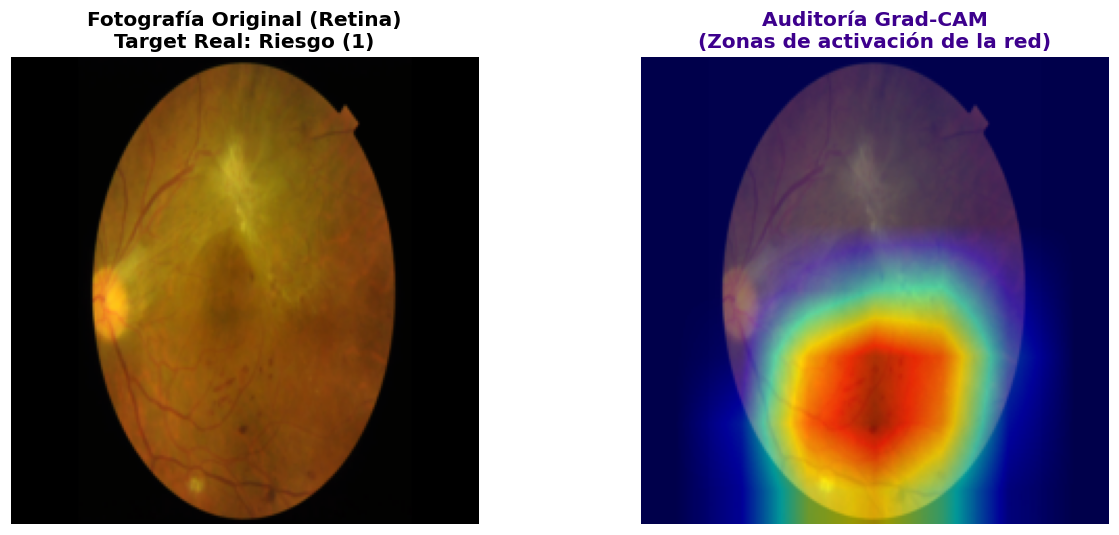

✅ Mapa de calor generado. Guarda esta gráfica para el documento de tu maestría.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 6 · Auditoría de IA: Explicabilidad con Grad-CAM (Rama A)
# Qué hace · Genera un mapa de calor sobre la imagen para evidenciar dónde mira la red.
# Por qué  · Requisito obligatorio (Nivel Estratégico) de la rúbrica del profesor.

# 1. Instalar la librería oficial de Grad-CAM de forma silenciosa
!pip install grad-cam -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("🔍 Iniciando Auditoría Visual Grad-CAM...")

# 2. Cargar los mejores pesos obtenidos en el entrenamiento
modelo_vision.load_state_dict(torch.load('/content/mejor_modelo_rama_A.pth'))
modelo_vision.eval()

# 3. Configurar la capa objetivo para Grad-CAM (El último bloque de ResNet50)
capa_objetivo = [modelo_vision.backbone.layer4[-1]]

# Construir el objeto GradCAM
cam = GradCAM(model=modelo_vision, target_layers=capa_objetivo)

# 4. Obtener un lote de imágenes de validación
imagenes_val, _, etiquetas_val = next(iter(loader_val))
indice_muestra = 0 # Tomamos el primer paciente del lote

imagen_tensor = imagenes_val[indice_muestra].unsqueeze(0).to(DEVICE)
etiqueta_real = etiquetas_val[indice_muestra].item()

# 5. Generar el mapa de calor
# target_category = None hace que use la clase con mayor probabilidad predicha
mapa_escala_grises = cam(input_tensor=imagen_tensor, targets=None)[0, :]

# 6. Desnormalizar la imagen original para poder visualizarla correctamente
img_original = imagenes_val[indice_muestra].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_original = std * img_original + mean
img_original = np.clip(img_original, 0, 1)

# Superponer el mapa de calor con los colores institucionales (ajustando el colormap)
visualizacion_cam = show_cam_on_image(img_original, mapa_escala_grises, use_rgb=True, colormap=cv2.COLORMAP_JET)

# 7. Graficar los resultados para el informe
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(img_original)
ejes[0].set_title(f"Fotografía Original (Retina)\nTarget Real: {'Riesgo (1)' if etiqueta_real==1 else 'Sano (0)'}", fontweight='bold')
ejes[0].axis('off')

ejes[1].imshow(visualizacion_cam)
ejes[1].set_title("Auditoría Grad-CAM\n(Zonas de activación de la red)", fontweight='bold', color=USTA_MORADO)
ejes[1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Mapa de calor generado. Guarda esta gráfica para el documento de tu maestría.")

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 7 · Rama B: Arquitectura Secuencial (LSTM)
# Qué hace · Define la red recurrente para procesar el historial de glucosa de 6 meses.
# Por qué  · Cumple la rúbrica exigiendo RNN/LSTM y mitigando el desvanecimiento del gradiente.

import torch.nn as nn

class RamaB_Secuencia(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(RamaB_Secuencia, self).__init__()

        # 1. Red LSTM (Long Short-Term Memory)
        # batch_first=True indica que los tensores entran con forma (Batch, Secuencia, Característica)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )

        # 2. Preparación para Fusión Multimodal (Embedding de 32 dimensiones)
        self.hidden_size = hidden_size

        # 3. Cabeza Clasificadora Propia (Para auditar la Rama B sola)
        self.clasificador = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x, retornar_embedding=False):
        # x shape: (Batch, 6 meses, 1 feature)
        # out contiene todas las salidas; h_n contiene el último estado oculto de la secuencia
        out, (h_n, c_n) = self.lstm(x)

        # Tomamos la "memoria final" de la última capa LSTM para representar todo el historial
        embedding = h_n[-1, :, :]

        # Generar diagnóstico basado solo en el historial de glucosa
        prediccion = self.clasificador(embedding)

        if retornar_embedding:
            return embedding, prediccion
        return prediccion

# Instanciar la Rama B y enviarla a la GPU
modelo_secuencia = RamaB_Secuencia(input_size=1, hidden_size=32, num_layers=2).to(DEVICE)
print(f"✅ Rama B (LSTM) instanciada y enviada a: {DEVICE.type.upper()}")
print(f"🧠 Capacidad de memoria temporal: {modelo_secuencia.hidden_size} características latentes.")

✅ Rama B (LSTM) instanciada y enviada a: CUDA
🧠 Capacidad de memoria temporal: 32 características latentes.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 8 · Entrenamiento y Checkpointing de la Rama B (Secuencia)
# Qué hace · Bucle de optimización que ajusta las compuertas de la LSTM.
# Por qué  · Evalúa el poder predictivo aislado del historial clínico del paciente.

import time
import copy
import torch.optim as optim

# Hiperparámetros
EPOCHS_B = 15 # LSTMs suelen necesitar unas épocas más para estabilizarse
criterio_B = nn.BCELoss()
optimizador_B = optim.Adam(modelo_secuencia.parameters(), lr=1e-3)

def entrenar_rama_b(modelo, loader_train, loader_val, criterio, optimizador, num_epochs):
    print("🚀 Iniciando entrenamiento de la Rama B (Historial Clínico LSTM)...")
    tiempo_inicio = time.time()

    mejor_loss_val = float('inf')
    mejores_pesos = copy.deepcopy(modelo.state_dict())
    historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        loss_train_acum = 0.0

        # Nota: Extraemos 'secuencias' (la segunda variable del DataLoader)
        for _, secuencias, etiquetas in loader_train:
            secuencias = secuencias.to(DEVICE)
            etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

            optimizador.zero_grad()
            salidas = modelo(secuencias, retornar_embedding=False)

            loss = criterio(salidas, etiquetas)
            loss.backward()
            optimizador.step()

            loss_train_acum += loss.item() * secuencias.size(0)

        loss_train_promedio = loss_train_acum / len(loader_train.dataset)
        historial['train_loss'].append(loss_train_promedio)

        # --- FASE DE VALIDACIÓN ---
        modelo.eval()
        loss_val_acum = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():
            for _, secuencias, etiquetas in loader_val:
                secuencias = secuencias.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

                salidas = modelo(secuencias, retornar_embedding=False)
                loss = criterio(salidas, etiquetas)
                loss_val_acum += loss.item() * secuencias.size(0)

                predicciones = (salidas >= 0.5).float()
                correctos += (predicciones == etiquetas).sum().item()
                total += etiquetas.size(0)

        loss_val_promedio = loss_val_acum / len(loader_val.dataset)
        acc_val = correctos / total

        historial['val_loss'].append(loss_val_promedio)
        historial['val_acc'].append(acc_val)

        # Imprimimos de forma más compacta
        print(f"Época {epoch+1}/{num_epochs} | Train Loss: {loss_train_promedio:.4f} | Val Loss: {loss_val_promedio:.4f} | Val Acc: {acc_val:.4f}")

        # Checkpointing
        if loss_val_promedio < mejor_loss_val:
            mejor_loss_val = loss_val_promedio
            mejores_pesos = copy.deepcopy(modelo.state_dict())

    tiempo_total = time.time() - tiempo_inicio
    print(f"\n✅ Entrenamiento de serie temporal completado en {tiempo_total:.1f} segundos.")

    modelo.load_state_dict(mejores_pesos)
    torch.save(modelo.state_dict(), '/content/mejor_modelo_rama_B.pth')
    print("💾 Mejor modelo temporal guardado como 'mejor_modelo_rama_B.pth'")

    return modelo, historial

# Ejecutar el entrenamiento temporal
modelo_secuencia, historial_B = entrenar_rama_b(
    modelo_secuencia, loader_train, loader_val, criterio_B, optimizador_B, EPOCHS_B
)

🚀 Iniciando entrenamiento de la Rama B (Historial Clínico LSTM)...
Época 1/15 | Train Loss: 0.6602 | Val Loss: 0.5202 | Val Acc: 0.9375
